#You Shall Not sPam(YSNP)
Trocadalho com o famoso termo da franquia Lord of Rings: You Shall Not Pass!

## Esteira ML Detecção de Spam

### **Célula 1: Importação das Bibliotecas e Carga dos Dados**

Primeiro, vamos importar as ferramentas necessárias e carregar o dataset diretamente da internet (UCI Machine Learning Repository) utilizando os nomes das colunas extraídos do arquivo que você enviou

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# URL direta para os dados no repositório UCI
url_dados = "https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data"

# Definição das colunas com base no arquivo .names fornecido
colunas = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our',
    'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail',
    'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses',
    'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp',
    'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs',
    'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
    'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re',
    'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_semicolon', 'char_freq_parenthesis',
    'char_freq_brackets', 'char_freq_exclamation', 'char_freq_dollar', 'char_freq_hash',
    'capital_run_length_average', 'capital_run_length_longest', 'capital_run_length_total', 'spam'
]

# Carregando o DataFrame
df = pd.read_csv(url_dados, header=None, names=colunas)
print(f"Dataset carregado com sucesso! Formato: {df.shape}")

Dataset carregado com sucesso! Formato: (4601, 58)


Célula 2: Estatísticas Descritivas Gerais

Aqui cumprimos o primeiro requisito, exibindo informações estruturais, dados estatísticos e a distribuição da nossa classe alvo (spam).

In [ ]:
print("--- Primeiras 5 Linhas do Dataset ---")
display(df.head())

print("\n--- Informações Gerais do Dataset ---")
display(df.info())

print("\n--- Estatísticas Descritivas das Variáveis de Letras Maiúsculas ---")
# Foco nas variáveis de contagem contínua para melhor legibilidade no resumo
display(df[['capital_run_length_average', 'capital_run_length_longest', 'capital_run_length_total']].describe())

print("\n--- Distribuição da Classe Alvo (0 = Não Spam, 1 = Spam) ---")
print(df['spam'].value_counts(normalize=True) * 100)

--- Primeiras 5 Linhas do Dataset ---


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_semicolon,char_freq_parenthesis,char_freq_brackets,char_freq_exclamation,char_freq_dollar,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1



--- Informações Gerais do Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64

None


--- Estatísticas Descritivas das Variáveis de Letras Maiúsculas ---


,capital_run_length_average,capital_run_length_longest,capital_run_length_total
count,4601.000000,4601.000000,4601.000000
mean,5.191515,52.172789,283.289285
std,31.729449,194.891310,606.347851
min,1.000000,1.000000,1.000000
25%,1.588000,6.000000,35.000000
50%,2.276000,15.000000,95.000000
75%,3.706000,43.000000,266.000000
max,1102.500000,9989.000000,15841.000000



--- Distribuição da Classe Alvo (0 = Não Spam, 1 = Spam) ---
spam
0    60.595523
1    39.404477
Name: proportion, dtype: float64


Célula 3: Transformação de Dados (Colunas e Linhas)

Para os requisitos de transformação:

    Transformação em Colunas: Aplicaremos a padronização (StandardScaler) nas colunas preditoras. Isso é essencial em esteiras de ML para deixar as variáveis numéricas na mesma escala.

    Transformação em Linhas: Removeremos possíveis linhas duplicadas do dataset para evitar vazamento de dados e viés no modelo.

In [ ]:
# 1. Transformação de LINHAS: Remoção de registros duplicados
linhas_antes = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True) # <- O truque está aqui! Reseta o índice de tudo junto
linhas_depois = df.shape[0]
print(f"Transformação de Linhas: Removidas {linhas_antes - linhas_depois} linhas duplicadas.")

# Separando preditores (X) e variável alvo (y)
X = df.drop(columns=['spam'])
y = df['spam']

# 2. Transformação de COLUNAS: Padronização da escala dos dados numéricos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertendo de volta para DataFrame mantendo o alinhamento
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print("Transformação de Colunas: Normalização Z-score aplicada com sucesso em todas as features.")

Transformação de Linhas: Removidas 391 linhas duplicadas.
Transformação de Colunas: Normalização Z-score aplicada com sucesso em todas as features.


Célula 4: Divisão em Treino, Validação e Teste

Vamos dividir a base respeitando a proporção clássica de 60% para Treino, 20% para Validação e 20% para Teste.

```
# Isto está formatado como código
```



In [ ]:
# Primeiro separa 20% para teste e 80% para o bloco inicial (treino + validação)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

# Do bloco inicial, separa 25% para validação (25% de 80% = 20% do total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print(f"Quantidade de dados de Treino: {X_train.shape[0]} ({len(X_train)/len(df)*100:.0f}%)")
print(f"Quantidade de dados de Validação: {X_val.shape[0]} ({len(X_val)/len(df)*100:.0f}%)")
print(f"Quantidade de dados de Teste: {X_test.shape[0]} ({len(X_test)/len(df)*100:.0f}%)")

Quantidade de dados de Treino: 2526 (60%)
Quantidade de dados de Validação: 842 (20%)
Quantidade de dados de Teste: 842 (20%)


Célula 5: Treinamento e Avaliação no Conjunto de Validação

Utilizaremos o algoritmo Random Forest (Floresta Aleatória), excelente para problemas de classificação binária complexos como detecção de Spam.

In [ ]:
# Instanciando e treinando o modelo
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# Predição no conjunto de validação para ajuste fino (se necessário)
y_val_pred = modelo.predict(X_val)
acc_val = accuracy_score(y_val, y_val_pred)
print(f"Acurácia no conjunto de Validação: {acc_val * 100:.2f}%")

Acurácia no conjunto de Validação: 94.77%


Célula 6: Avaliação Final no Conjunto de Teste (Matriz de Confusão e Acurácia)

Aqui geramos a avaliação final da esteira utilizando os dados de Teste (que nunca foram vistos pelo modelo), exibindo a Matriz de Confusão de forma visual.

Acurácia Final do Modelo nos Dados de Teste: 94.66%

--- Relatório de Classificação ---
              precision    recall  f1-score   support

    Não Spam       0.94      0.97      0.96       506
        Spam       0.95      0.91      0.93       336

    accuracy                           0.95       842
   macro avg       0.95      0.94      0.94       842
weighted avg       0.95      0.95      0.95       842



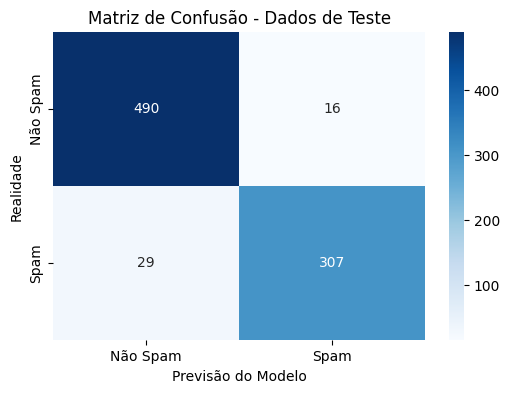

In [ ]:
# Predição final com dados de teste
y_test_pred = modelo.predict(X_test)
acuracia_final = accuracy_score(y_test, y_test_pred)

print(f"Acurácia Final do Modelo nos Dados de Teste: {acuracia_final * 100:.2f}%\n")
print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_test_pred, target_names=['Não Spam', 'Spam']))

# Gerando a Matriz de Confusão Visual
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Não Spam', 'Spam'], yticklabels=['Não Spam', 'Spam'])
plt.title('Matriz de Confusão - Dados de Teste')
plt.ylabel('Realidade')
plt.xlabel('Previsão do Modelo')
plt.show()

Célula 7: Demonstração Prática de uma Predição Única

Para simular a esteira em produção, pegamos uma única linha aleatória do conjunto de testes, passamos pelo modelo e exibimos o resultado traduzido.

In [ ]:
# Seleciona uma amostra aleatória do conjunto de teste
amostra_exemplo = X_test.sample(1, random_state=7)
classe_real = y_test.loc[amostra_exemplo.index].values[0] # Agora os índices vão bater perfeitamente!

# Realiza a predição da amostra
predicao_unica = modelo.predict(amostra_exemplo)[0]
probabilidades = modelo.predict_proba(amostra_exemplo)[0]

# Tradução do resultado
status_real = "Spam" if classe_real == 1 else "E-mail Legítimo (Não Spam)"
status_predito = "Spam" if predicao_unica == 1 else "E-mail Legítimo (Não Spam)"

print("--- Simulação de Entrada de Novo E-mail na Esteira ---")
print(f"Resultado Real do E-mail selecionado: {status_real}")
print(f"Resultado da Predição do Modelo: {status_predito}")
print(f"Probabilidade de ser Não-Spam: {probabilidades[0]*100:.2f}% | Probabilidade de ser Spam: {probabilidades[1]*100:.2f}%")

--- Simulação de Entrada de Novo E-mail na Esteira ---
Resultado Real do E-mail selecionado: Spam
Resultado da Predição do Modelo: Spam
Probabilidade de ser Não-Spam: 23.00% | Probabilidade de ser Spam: 77.00%
